<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>



# **Final Project: Boston Housing**


##### Estimated time needed: **60** minutes


#### Import the required libraries we need for the lab.


In [1]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import pearsonr

<ipython-input-2-38555f3fc93e>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


#### Read the dataset in the csv file from the URL


In [3]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [4]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


## Task 1: Become familiar with the dataset

| Variable | Description |
| :--- | :--- |
| CRIM | Per capita crime rate by town |
| ZN | Proportion of residential land zoned for lots over 25000 sq.ft |
| INDUS | Proportion of non-retail business acres per town |
| CHAS | Charles River dummy variable (1 if tract bounds river; 0 otherwise) |
| NOX | Nitric oxides concentration (parts per 10 million) |
| RM | Average number of rooms per dwelling |
| AGE | Proportion of owner-occupied units built prior to 1940 |
| DIS | Weighted distances to five Boston employment centers |
| RAD | Index of accessibility to radial highways |
| TAX | Full-value property-tax rate per $10000 |
| PTRATIO | Pupil-teacher ratio by town |
| LSTAT | % lower status of the population |
| MEDV | Median value of owner-occupied homes in $1000's |

Display the first 5 rows of the dataset.

In [5]:
boston_df.head(5)

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33,36.2


Display the data types of each column

In [6]:
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV        506 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.4 KB


Check for missing values in each column

In [7]:
boston_df.isna().sum()
print(boston_df.isnull().sum() / len(boston_df) * 100)
print(boston_df.info())

Unnamed: 0    0.0
CRIM          0.0
ZN            0.0
INDUS         0.0
CHAS          0.0
NOX           0.0
RM            0.0
AGE           0.0
DIS           0.0
RAD           0.0
TAX           0.0
PTRATIO       0.0
LSTAT         0.0
MEDV          0.0
dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV    

Check for duplicate rows

In [8]:
print(boston_df.duplicated().sum())
print(boston_df[boston_df.duplicated()])
print(boston_df[boston_df.duplicated(keep=False)])

0
Empty DataFrame
Columns: [Unnamed: 0, CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, LSTAT, MEDV]
Index: []
Empty DataFrame
Columns: [Unnamed: 0, CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, LSTAT, MEDV]
Index: []


Display the correlation matrix of the dataset

--- Raw Correlation Matrix ---
            Unnamed: 0  CRIM    ZN  INDUS  CHAS   NOX    RM   AGE   DIS   RAD  \
Unnamed: 0        1.00  0.41 -0.10   0.40 -0.00  0.40 -0.08  0.20 -0.30  0.69   
CRIM              0.41  1.00 -0.20   0.41 -0.06  0.42 -0.22  0.35 -0.38  0.63   
ZN               -0.10 -0.20  1.00  -0.53 -0.04 -0.52  0.31 -0.57  0.66 -0.31   
INDUS             0.40  0.41 -0.53   1.00  0.06  0.76 -0.39  0.64 -0.71  0.60   
CHAS             -0.00 -0.06 -0.04   0.06  1.00  0.09  0.09  0.09 -0.10 -0.01   
NOX               0.40  0.42 -0.52   0.76  0.09  1.00 -0.30  0.73 -0.77  0.61   
RM               -0.08 -0.22  0.31  -0.39  0.09 -0.30  1.00 -0.24  0.21 -0.21   
AGE               0.20  0.35 -0.57   0.64  0.09  0.73 -0.24  1.00 -0.75  0.46   
DIS              -0.30 -0.38  0.66  -0.71 -0.10 -0.77  0.21 -0.75  1.00 -0.49   
RAD               0.69  0.63 -0.31   0.60 -0.01  0.61 -0.21  0.46 -0.49  1.00   
TAX               0.67  0.58 -0.31   0.72 -0.04  0.67 -0.29  0.51 -0.53  0.91 

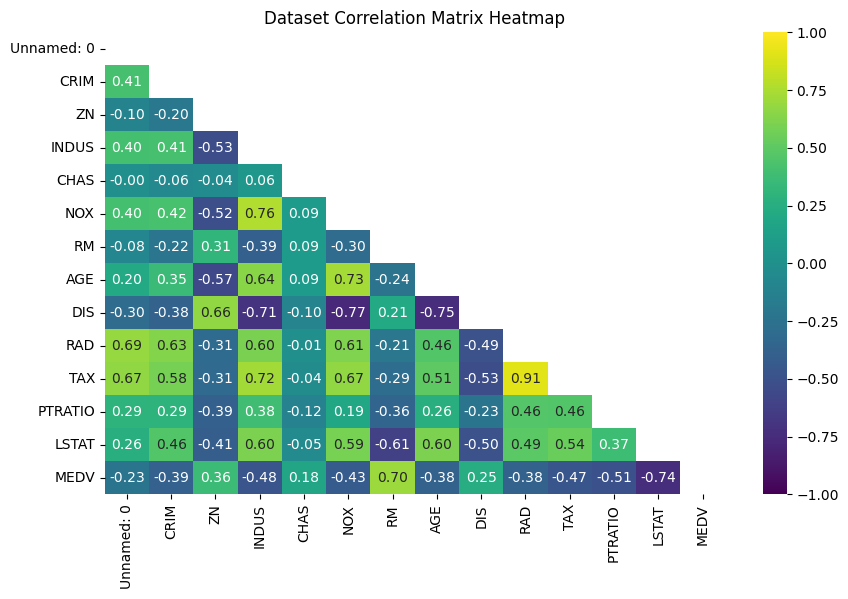

In [9]:
corr_matrix = boston_df.corr(numeric_only=True)
print("--- Raw Correlation Matrix ---")
print(corr_matrix.round(2))
print("\n")
plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,  
    cmap="viridis",
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Dataset Correlation Matrix Heatmap")
plt.show()

## Task 2: Generate Descriptive Statistics and Visualizations

Display descriptive statistics of the dataset

In [10]:
print(boston_df.describe())

       Unnamed: 0        CRIM          ZN       INDUS        CHAS         NOX  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean   252.500000    3.613524   11.363636   11.136779    0.069170    0.554695   
std    146.213884    8.601545   23.322453    6.860353    0.253994    0.115878   
min      0.000000    0.006320    0.000000    0.460000    0.000000    0.385000   
25%    126.250000    0.082045    0.000000    5.190000    0.000000    0.449000   
50%    252.500000    0.256510    0.000000    9.690000    0.000000    0.538000   
75%    378.750000    3.677083   12.500000   18.100000    0.000000    0.624000   
max    505.000000   88.976200  100.000000   27.740000    1.000000    0.871000   

               RM         AGE         DIS         RAD         TAX     PTRATIO  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     6.284634   68.574901    3.795043    9.549407  408.237154   18.455534   
std      0.702617   28.1488

Create a boxplot for **MEDV** (Median value of owner-occupied homes).

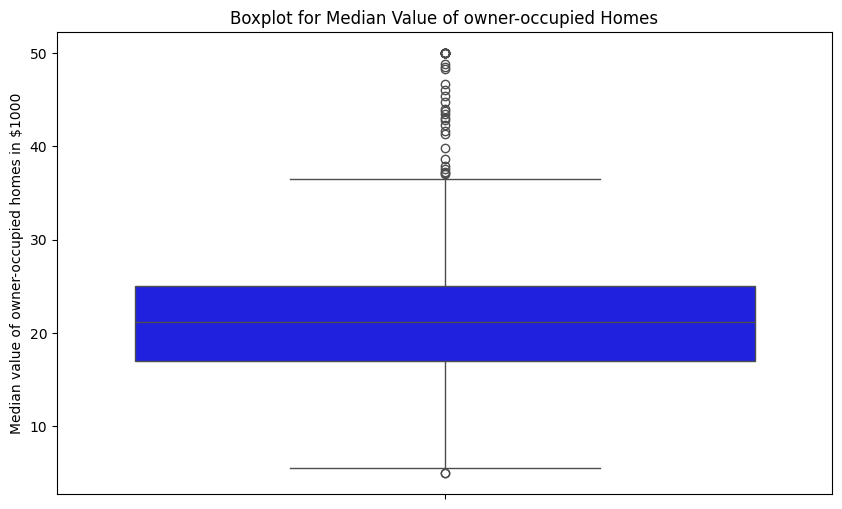

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(y='MEDV', data=boston_df, color='blue')
plt.title('Boxplot for Median Value of owner-occupied Homes')
plt.ylabel('Median value of owner-occupied homes in $1000')
plt.show()

Create a bar plot for **CHAS** (Charles River dummy variable).

<Figure size 1000x600 with 0 Axes>

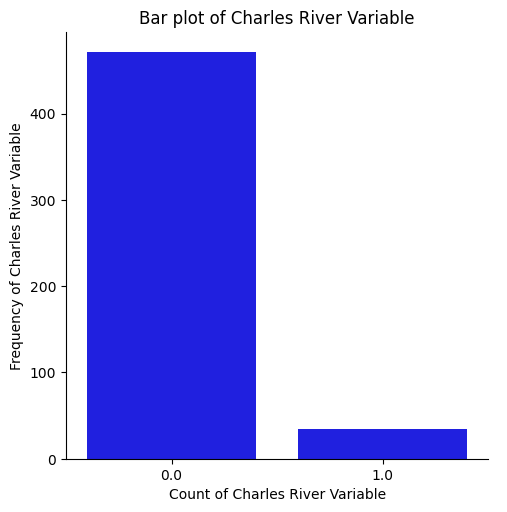

In [12]:
plt.figure(figsize=(10, 6))
sns.catplot(x='CHAS', kind='count', data=boston_df, color='blue')
plt.title('Bar plot of Charles River Variable')
plt.ylabel('Frequency of Charles River Variable')
plt.xlabel('Count of Charles River Variable')
plt.show()

Discretize **AGE** into three groups and create a boxplot of **MEDV** versus these groups

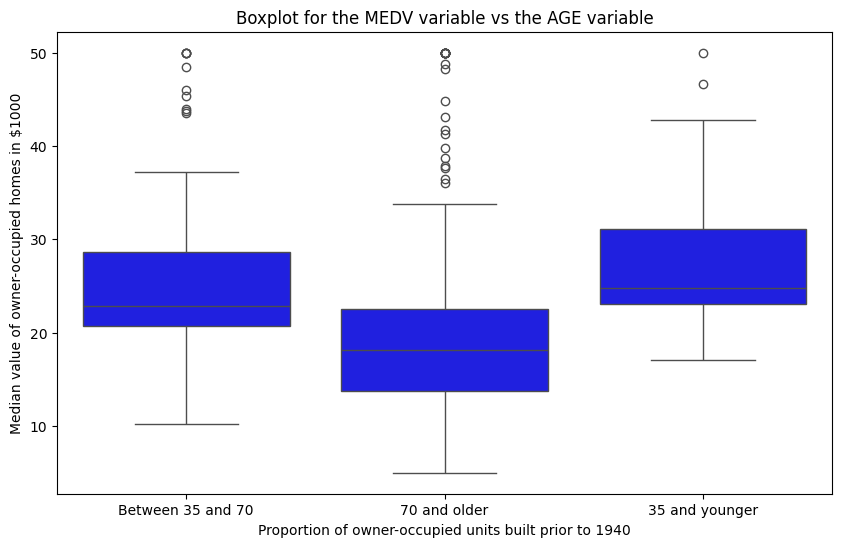

In [13]:
boston_df.loc[boston_df['AGE'] <= 30, 'Age_Group'] = "35 and younger"
boston_df.loc[(boston_df['AGE'] > 30) & (boston_df['AGE'] < 70), 'Age_Group'] = "Between 35 and 70"
boston_df.loc[(boston_df['AGE'] >= 70), 'Age_Group'] = "70 and older"
plt.figure(figsize=(10, 6))
sns.boxplot(x = 'Age_Group', y = 'MEDV', data = boston_df, color='blue')
plt.title('Boxplot for the MEDV variable vs the AGE variable')
plt.ylabel('Median value of owner-occupied homes in $1000')
plt.xlabel('Proportion of owner-occupied units built prior to 1940')
plt.show()

Create a scatter plot showing the relationship between **NOX** (nitric oxide concentrations) and **INDUS** (non-retail business acres).

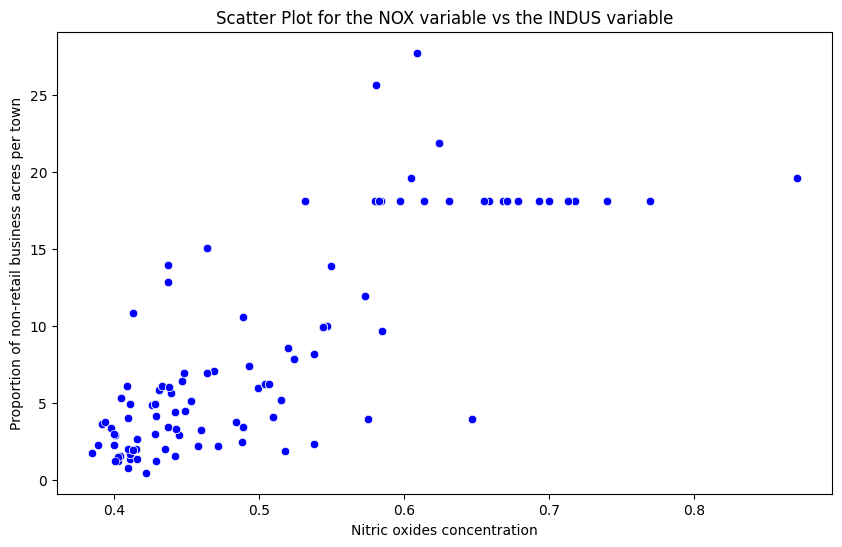

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='NOX', y='INDUS', data=boston_df, color='blue')
plt.title('Scatter Plot for the NOX variable vs the INDUS variable')
plt.ylabel('Proportion of non-retail business acres per town')
plt.xlabel('Nitric oxides concentration')
plt.show()

Create a histogram for **PTRATIO** (pupil-teacher ratio).

<Figure size 1000x600 with 0 Axes>

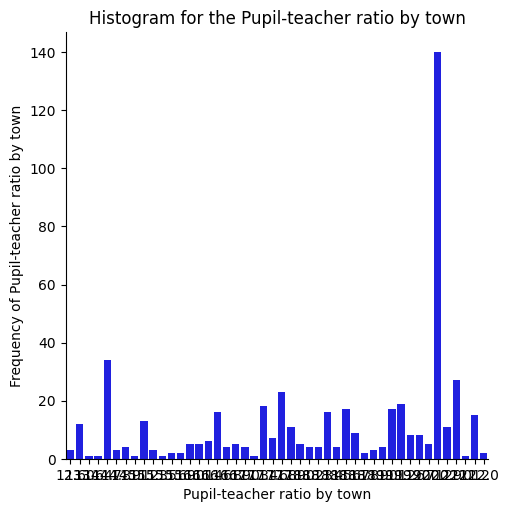

In [15]:
plt.figure(figsize=(10, 6))
sns.catplot(x='PTRATIO', kind='count', data=boston_df, color='blue')
plt.title('Histogram for the Pupil-teacher ratio by town')
plt.ylabel('Frequency of Pupil-teacher ratio by town')
plt.xlabel('Pupil-teacher ratio by town')
plt.show()

## Task 3: Apply Statistical Tests

Use **Levene’s test** to check if the variances of **MEDV** for homes bounded by the Charles River (**CHAS = 1**) and those not bounded (**CHAS = 0**) are equal

In [16]:
group_bounded = boston_df[boston_df['CHAS'] == 1]['MEDV']
group_not_bounded = boston_df[boston_df['CHAS'] == 0]['MEDV']
stat, p_value = stats.levene(group_bounded, group_not_bounded, center='median')
print(f"Levene's Test Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The variances are significantly different (unequal).")
else:
    print("Fail to reject the null hypothesis: The variances are equal (homogeneous).")

Levene's Test Statistic: 4.5903
p-value: 0.0326
Reject the null hypothesis: The variances are significantly different (unequal).


Perform a **T-test** to determine if there is a significant difference in **MEDV** between homes bounded and not bounded by the Charles River.

In [17]:
bounded = boston_df[boston_df['CHAS'] == 1]['MEDV']
not_bounded = boston_df[boston_df['CHAS'] == 0]['MEDV']
t_stat, p_value = stats.ttest_ind(bounded, not_bounded, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 3.1133
P-value: 0.0036


Conduct an **ANOVA test** to compare MEDV among the three **AGE** groups created earlier

In [18]:
boston_df['AGE_GROUP'] = pd.qcut(boston_df['AGE'], q=3, labels=['Low', 'Medium', 'High'])
group_1 = boston_df[boston_df['AGE_GROUP'] == 'Low']['MEDV']
group_2 = boston_df[boston_df['AGE_GROUP'] == 'Medium']['MEDV']
group_3 = boston_df[boston_df['AGE_GROUP'] == 'High']['MEDV']
f_stat, p_val = stats.f_oneway(group_1, group_2, group_3)
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_val:.4e}")
alpha = 0.05
if p_val < alpha:
    print("Conclusion: Reject the null hypothesis. There is a significant difference in MEDV among the age groups.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no significant difference in MEDV among the age groups.")

F-Statistic: 41.4402
P-Value: 2.1897e-17
Conclusion: Reject the null hypothesis. There is a significant difference in MEDV among the age groups.


Perform a **Pearson correlation test** to assess the relationship between **NOX** and **INDUS**

In [19]:
x = boston_df['NOX']
y = boston_df['INDUS']
corr, p_value = pearsonr(x, y)
print(f"Pearson Correlation Coefficient (r): {corr:.4f}")
print(f"P-value: {p_value:.4e}")
if p_value < 0.05:
    print("Result: The correlation is statistically significant.")
else:
    print("Result: The correlation is NOT statistically significant.")

Pearson Correlation Coefficient (r): 0.7637
P-value: 7.9134e-98
Result: The correlation is statistically significant.


Fit a **simple linear regression model** to evaluate the impact of **DIS** (distance to employment centres) on **MEDV**. Report and interpret the regression results.

In [20]:
X = boston_df['DIS']
y = boston_df['MEDV']
X_with_constant = sm.add_constant(X)
model = sm.OLS(y, X_with_constant)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                   MEDV   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     33.58
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           1.21e-08
Time:                        20:47:06   Log-Likelihood:                -1823.9
No. Observations:                 506   AIC:                             3652.
Df Residuals:                     504   BIC:                             3660.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3901      0.817     22.499      0.0